In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("C:/Users/user/Documents/Data Analysis/MY  PROJECT/CREDIT DEFAULT RISK MODELING/PYTHON/german_credit_clean.csv")
df.head()

In [73]:
print(df.head())

  checking_account  duration_months credit_history purpose  credit_amount  \
0              A12                6            A32     A43            753   
1              A12               18            A33     A49           2427   
2              A14               24            A33     A40           2538   
3              A12               15            A31     A40           1264   
4              A12               30            A34     A42           8386   

  savings_account employment_since  installment_rate personal_status_sex  \
0             A61              A73                 2                 A92   
1             A65              A75                 4                 A93   
2             A61              A75                 4                 A93   
3             A62              A73                 2                 A94   
4             A61              A74                 2                 A93   

  other_debtors  ...  age_years other_installment_plans  housing  \
0          A

In [ ]:
print(df['credit_history'].unique())
print(df['savings_account'].unique())
print(df['employment_since'].unique())

In [ ]:
print(df.dtypes)
print(df.describe())

In [ ]:
df_encoded = df_encoded.astype(int)

In [ ]:
df_encoded = pd.get_dummies(df, drop_first=True)

In [ ]:
print(df_encoded.head())
print(df_encoded.shape)

In [ ]:
df_encoded.shape

In [ ]:
!pip install matplotlib seaborn

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
X = df_encoded.drop(['default_flag', 'credit_risk'], axis=1)
y = df_encoded['default_flag']

In [ ]:
df["default_flag"].value_counts()

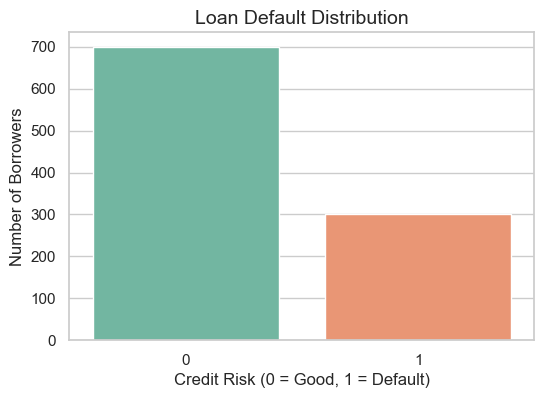

In [83]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

plt.figure(figsize=(6,4))

sns.countplot(x=df["default_flag"], hue=df["default_flag"], palette="Set2", legend=False)

plt.title("Loan Default Distribution", fontsize=14)
plt.xlabel("Credit Risk (0 = Good, 1 = Default)")
plt.ylabel("Number of Borrowers")

plt.savefig("assets/images/default_distribution.png", dpi=300, bbox_inches='tight')

plt.show()

Insight: Target Distribution

The dataset shows a moderate class imbalance, with approximately 70% of borrowers classified as non-default and 30% as default.

This imbalance indicates that a model optimized purely for accuracy may favor the majority class, potentially overlooking high-risk borrowers.

As a result, accuracy alone is not a sufficient evaluation metric for this problem, reinforcing the need for cost-sensitive evaluation and threshold optimization in the modeling phase.

In [ ]:
y.head()

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape

In [ ]:
import sklearn
print(sklearn.__version__)

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
model = LogisticRegression(max_iter=4000)

model.fit(X_train, y_train)

In [ ]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [ ]:
y_pred = model.predict(X_test_scaled)
y_pred[:10]

In [ ]:
y_prob = model.predict_proba(X_test_scaled) 
y_prob[:5]

In [75]:
from sklearn.metrics import accuracy_score

print(accuracy_score(y_test, y_pred))

0.685


In [76]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred))

[[95 43]
 [20 42]]


In [ ]:
import numpy as np

y_prob = model.predict_proba(X_test_scaled)[:, 1]

# New threshold
threshold = 0.5

y_pred_new = (y_prob >= threshold).astype(int)

In [ ]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred_new))

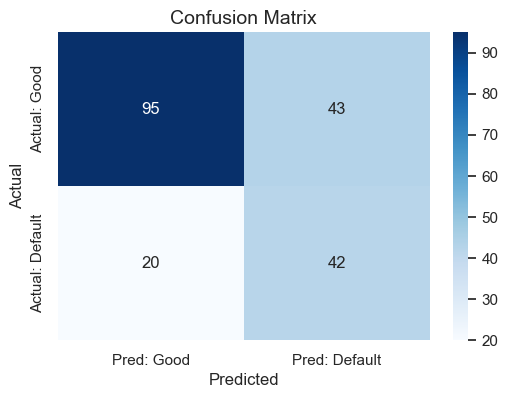

In [77]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.heatmap(cm, 
            annot=True, 
            fmt='d', 
            cmap='Blues',
            xticklabels=['Pred: Good', 'Pred: Default'],
            yticklabels=['Actual: Good', 'Actual: Default'])

plt.title("Confusion Matrix", fontsize=14)
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("assets/images/confusion_matrix.png", dpi=300, bbox_inches='tight')

plt.show()

Insight: Model Prediction Performance

The confusion matrix highlights the trade-offs in model predictions.

While the model correctly identifies a significant number of good borrowers and defaulters, it also makes two critical types of errors:

False Positives (43): Creditworthy borrowers incorrectly classified as high-risk, leading to potential lost business opportunities
False Negatives (20): High-risk borrowers incorrectly approved, representing direct financial risk to the lender

Given that false negatives carry a significantly higher cost, reducing these errors is critical for effective risk management.

This reinforces the need for threshold optimization to better align model decisions with business objectives.

In [ ]:
from sklearn.metrics import accuracy_score

print(accuracy_score(y_test, y_pred_new))

In [ ]:
y_prob[:20]

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix

thresholds = [0.5, 0.4, 0.3, 0.2, 0.1]

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    cm = confusion_matrix(y_test, y_pred_t)
    
    TN, FP, FN, TP = cm.ravel()
    
    cost = (FN * 5) + (FP * 1)
    
    print(f"Threshold: {t}")
    print(cm)
    print(f"Cost: {cost}")
    print("------")

In [ ]:
thresholds = [0.5, 0.4, 0.3, 0.2, 0.1]
costs = [143, 140, 144, 147, 129]

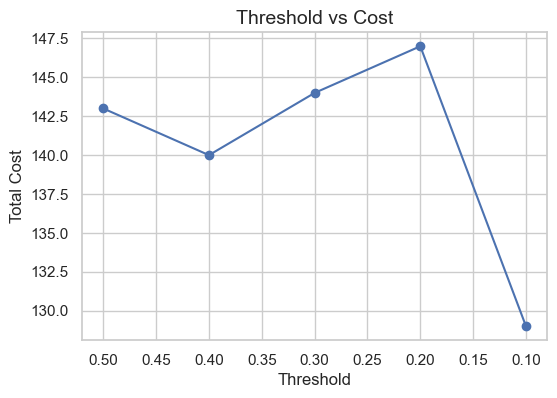

In [78]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.plot(thresholds, costs, marker='o')

plt.title("Threshold vs Cost", fontsize=14)
plt.xlabel("Threshold")
plt.ylabel("Total Cost")

plt.gca().invert_xaxis()  # So 0.5 → 0.1 flows left to right

plt.savefig("assets/images/threshold_vs_cost.png", dpi=300, bbox_inches='tight')

plt.show()

Insight: Threshold Optimization

The relationship between classification threshold and total cost reveals a clear trade-off between different types of prediction errors.

As the threshold decreases, the model becomes more sensitive to identifying high-risk borrowers, reducing the number of costly false negatives.

The optimal threshold is observed at 0.1, where total cost is minimized. This indicates that prioritizing the detection of high-risk borrowers, even at the expense of rejecting more applicants, leads to better financial outcomes.

This highlights the importance of aligning model decisions with business cost structures rather than relying on default classification thresholds.

In [ ]:
model.coef_

In [ ]:
import pandas as pd

coefficients = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_[0]
})

coefficients.head()

In [ ]:
coefficients_sorted = coefficients.sort_values(by='Coefficient', ascending=False)

coefficients_sorted.head(10)

In [ ]:
coefficients_sorted.tail(10)

In [ ]:
top_positive = coefficients_sorted.head(10)
top_negative = coefficients_sorted.tail(10)

In [ ]:
import pandas as pd

top_features = pd.concat([top_positive, top_negative])

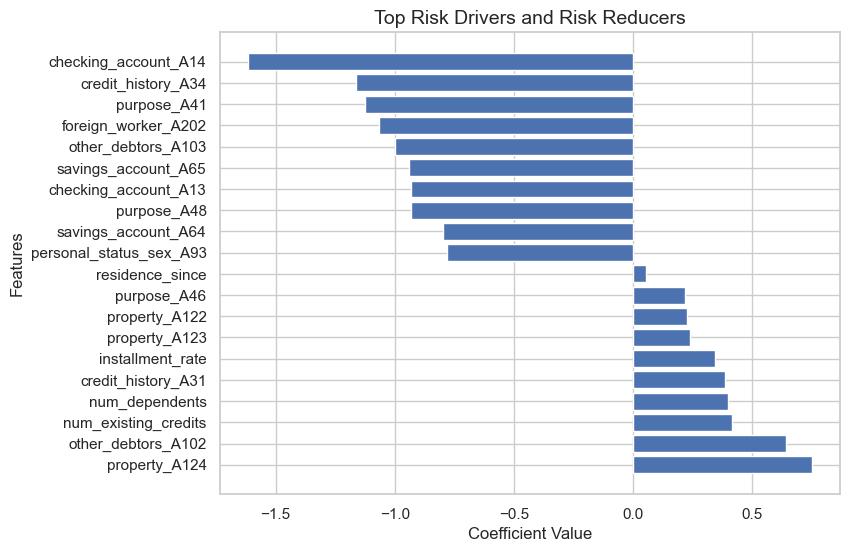

In [79]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.barh(top_features['Feature'], top_features['Coefficient'])

plt.title("Top Risk Drivers and Risk Reducers", fontsize=14)
plt.xlabel("Coefficient Value")
plt.ylabel("Features")

plt.savefig("assets/images/feature_importance.png", dpi=300, bbox_inches='tight')

plt.show()

Insight: Key Drivers of Default Risk

The feature importance analysis highlights the key factors influencing borrower default risk.

Variables with positive coefficients increase the likelihood of default, while those with negative coefficients indicate lower risk.

The model identifies financial pressure indicators such as existing credit obligations, number of dependents, and weaker credit history as major contributors to default risk.

Conversely, strong financial stability signals — including higher savings levels, strong account status, and positive credit history — significantly reduce the probability of default.

This reinforces the importance of evaluating both borrower capacity and financial behavior when making lending decisions.

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

In [ ]:
y_probs = model.predict_proba(X_test)[:, 1]

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

In [80]:
auc_score = roc_auc_score(y_test, y_probs)
print("AUC:", auc_score)

AUC: 0.7385460495558672


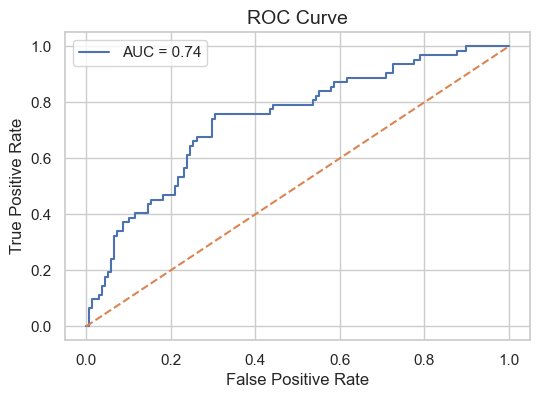

In [81]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
plt.plot([0, 1], [0, 1], linestyle='--')  # random model line

plt.title("ROC Curve", fontsize=14)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.savefig("assets/images/roc_curve.png", dpi=300, bbox_inches='tight')
plt.show()

Insight: Model Discrimination Ability (ROC-AUC)

The ROC curve illustrates the model’s ability to distinguish between defaulting and non-defaulting borrowers across different classification thresholds.

The AUC score indicates how well the model ranks high-risk borrowers relative to low-risk borrowers. A higher AUC reflects stronger discriminatory power.

While the model demonstrates reasonable separation capability, the ROC curve also highlights that threshold selection remains critical, as business impact depends on the trade-off between detecting defaulters and minimizing unnecessary rejections.